# Análise preditiva das emissões de CO₂

Este notebook desenvolve uma análise preditiva com base no ficheiro `dataset5.csv`, Global Data on Sustainable Energy, relativo a indicadores globais de energia sustentável. O objetivo é prever a variável contínua `Value_co2_emissions_kt_by_country`, correspondente às emissões de CO₂ por país.

A análise utiliza variáveis numéricas associadas à produção de eletricidade, consumo energético, área territorial e percentagem de energia renovável, bem como a variável categórica `Entity`, que identifica o país ou região. Esta variável categórica é integrada no modelo através de codificação `OneHotEncoder`.

São comparados dois modelos supervisionados de regressão:

- Regressão Linear;
- Random Forest Regressor.

A avaliação dos modelos é realizada através de duas estratégias:

- validação Hold-out, com 70% dos dados para treino e 30% para teste;
- validação cruzada K-Fold, com 10 folds.

As métricas utilizadas são o MAE, o RMSE e o coeficiente de determinação R².

## Importação de bibliotecas e leitura inicial do dataset

Nesta etapa são importadas as bibliotecas necessárias para a análise, visualização dos dados, pré-processamento e modelação preditiva. É também realizada a leitura do CSV, permitindo observar os tipos de variáveis presentes no dataset.

In [30]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12


df = pd.read_csv("dataset5.csv")

print(df.dtypes)


Entity                                                                  str
Year                                                                float64
Access to electricity (% of population)                             float64
Access to clean fuels for cooking                                   float64
Renewable-electricity-generating-capacity-per-capita                float64
Financial flows to developing countries (US $)                      float64
Renewable energy share in the total final energy consumption (%)    float64
Electricity from fossil fuels (TWh)                                 float64
Electricity from nuclear (TWh)                                      float64
Electricity from renewables (TWh)                                   float64
Low-carbon electricity (% electricity)                              float64
Primary energy consumption per capita (kWh/person)                  float64
Energy intensity level of primary energy (MJ/$2017 PPP GDP)         float64
Value_co2_em

## 1. Análise de correlação entre variáveis numéricas

É analisada a correlação de Pearson entre as variáveis numéricas do dataset, que permite identificar relações lineares entre a variável alvo e as restantes variáveis facilitando a seleção das variáveis explicativas.

A matriz de correlação avalia relações lineares entre variáveis numéricas, desta maneira a variável categórica `Entity` não é incluída nesta etapa.

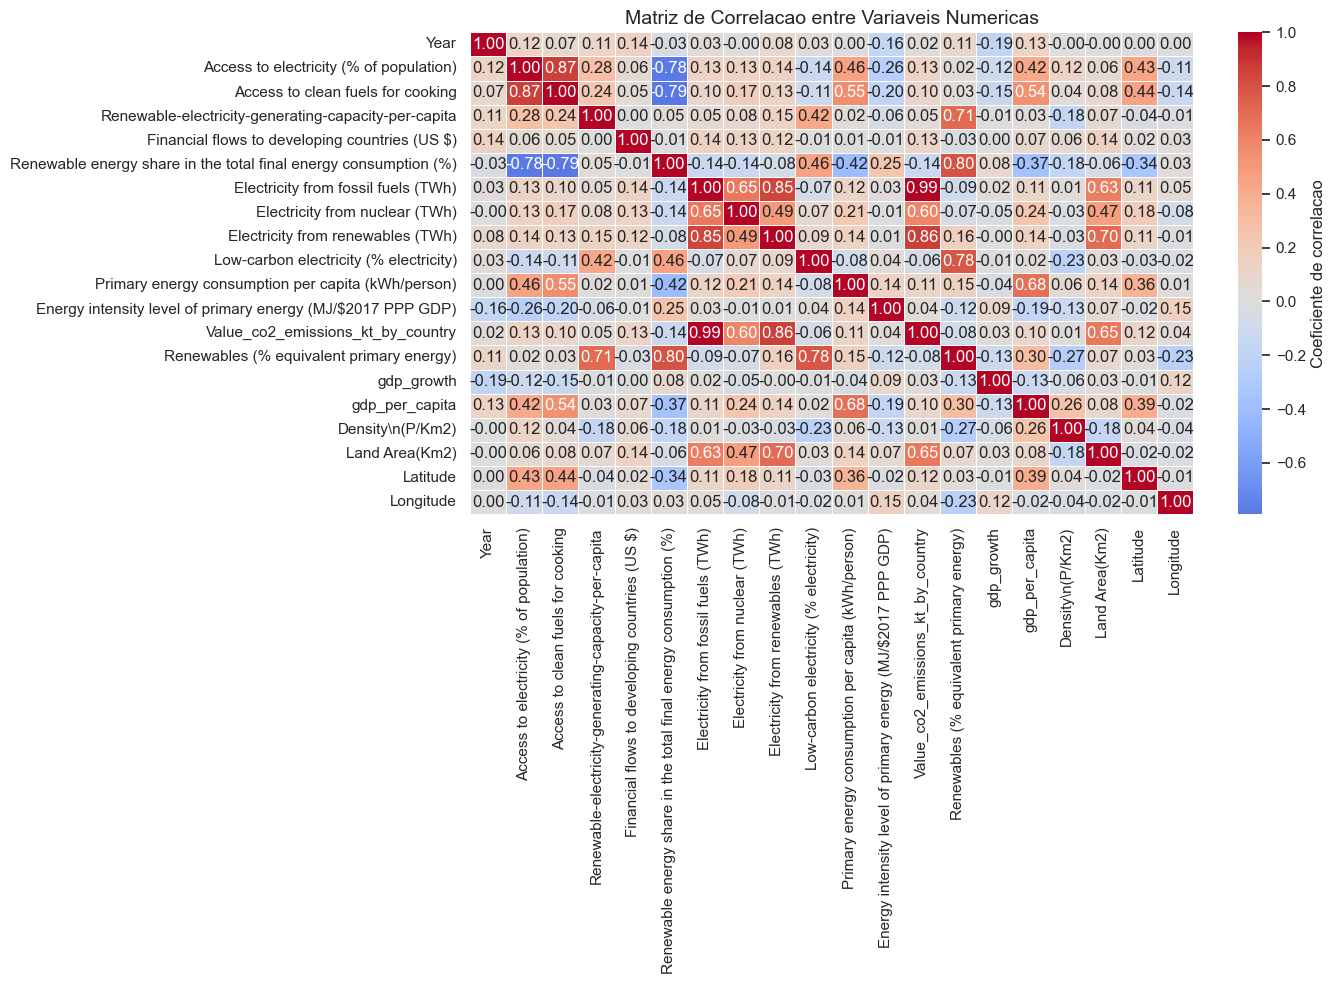

In [31]:
df_numeric = df.select_dtypes(include=["number"])

correlation_matrix = df_numeric.corr(method="pearson")

plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    cbar_kws={"label": "Coeficiente de correlacao"}
)

plt.title("Matriz de Correlacao entre Variaveis Numericas")
plt.tight_layout()
plt.show()


## 2. Carregamento e seleção dos dados

Nesta etapa, o ficheiro CSV é carregado e são selecionadas as variáveis utilizadas na análise preditiva. A variável alvo escolhida é `Value_co2_emissions_kt_by_country`, por representar as emissões de CO₂ que se pretende prever.

As variáveis explicativas foram selecionadas por apresentarem correlação com as emissões de CO₂, nomeadamente através da produção de eletricidade por fonte energética, da percentagem de energia renovável e da dimensão territorial do país.

Variável alvo:

- `Value_co2_emissions_kt_by_country`

Variáveis explciativas numéricas:

- `Electricity from fossil fuels (TWh)`;
- `Electricity from renewables (TWh)`;
- `Electricity from nuclear (TWh)`;
- `Land Area (Km2)`;
- `Renewable energy share in the total final energy consumption (%)`.

Variável explicativa categórica:

- `Entity`.

A variável `Entity` é mantida porque o país ou região pode conter informação contextual relevante para explicar diferenças estruturais nas emissões de CO₂.


In [32]:
# Definição do dataset, variável alvo e variáveis explicativas

DATA_PATH = "dataset5.csv"

TARGET_COLUMN = "Value_co2_emissions_kt_by_country"

NUMERIC_FEATURES = [
    "Electricity from fossil fuels (TWh)",
    "Electricity from renewables (TWh)",
    "Electricity from nuclear (TWh)",
    "Land Area (Km2)",
    "Renewable energy share in the total final energy consumption (%)",
]

CATEGORICAL_FEATURES = ["Entity"]

FEATURE_COLUMNS = NUMERIC_FEATURES + CATEGORICAL_FEATURES


In [33]:
# Carregamento e visualização inicial do dataset
df = pd.read_csv(DATA_PATH)


df = df.rename(columns={
    "Land Area(Km2)": "Land Area (Km2)",
    "Density\n(P/Km2)": "Density (P/Km2)",
})

print("Dimensao original do dataset:", df.shape)
display(df.head())


Dimensao original do dataset: (3649, 21)


,Entity,Year,Access to electricity (% of population),Access to clean fuels for cooking,Renewable-electricity-generating-capacity-per-capita,Financial flows to developing countries (US $),Renewable energy share in the total final energy consumption (%),Electricity from fossil fuels (TWh),Electricity from nuclear (TWh),Electricity from renewables (TWh),...,Primary energy consumption per capita (kWh/person),Energy intensity level of primary energy (MJ/$2017 PPP GDP),Value_co2_emissions_kt_by_country,Renewables (% equivalent primary energy),gdp_growth,gdp_per_capita,Density\n(P/Km2),Land Area (Km2),Latitude,Longitude
0,Afghanistan,2000.0,1.613591,6.2,9.22,20000.0,44.99,0.16,0.0,0.31,...,302.59482,1.64,760.000000,NaN,NaN,NaN,60.0,652230.0,33.93911,67.709953
1,Afghanistan,2001.0,4.074574,7.2,8.86,130000.0,45.60,0.09,0.0,0.50,...,236.89185,1.74,730.000000,NaN,NaN,NaN,60.0,652230.0,33.93911,67.709953
2,Afghanistan,2002.0,9.409158,8.2,8.47,3950000.0,37.83,0.13,0.0,0.56,...,210.86215,1.40,1029.999971,NaN,NaN,179.426579,60.0,652230.0,33.93911,67.709953
3,Afghanistan,2003.0,14.738506,9.5,8.09,25970000.0,36.66,0.31,0.0,0.63,...,229.96822,1.40,1220.000029,NaN,8.832278,190.683814,60.0,652230.0,33.93911,67.709953
4,Afghanistan,2004.0,20.064968,10.9,7.75,NaN,44.24,0.33,0.0,0.56,...,204.23125,1.20,1029.999971,NaN,1.414118,211.382074,60.0,652230.0,33.93911,67.709953


In [34]:
# Confirmação das variáveis categóricas usadas no modelo
print("Variáveis categóricas incluídas no modelo:", CATEGORICAL_FEATURES)

for column in CATEGORICAL_FEATURES:
    print(f"{column}: {df[column].nunique()} categorias unicas")


Variáveis categóricas incluídas no modelo: ['Entity']
Entity: 276 categorias unicas


In [35]:
# Verificação da existência das colunas necessárias
required_columns = FEATURE_COLUMNS + [TARGET_COLUMN]
missing_columns = [col for col in required_columns if col not in df.columns]

if missing_columns:
    raise ValueError(
        "As seguintes colunas não foram encontradas no dataset: "
        f"{missing_columns}\n\nColunas disponiveis:\n{list(df.columns)}"
    )


In [36]:
# Preparação das colunas relevantes e tratamento inicial dos dados
data = df[required_columns].copy()

for column in NUMERIC_FEATURES + [TARGET_COLUMN]:
    data[column] = pd.to_numeric(data[column], errors="coerce")


data = data.dropna(subset=[TARGET_COLUMN])

print("Dimensao apos remover linhas com alvo nulo:", data.shape)
display(data[NUMERIC_FEATURES + [TARGET_COLUMN]].describe().T)

display(
    data[CATEGORICAL_FEATURES]
    .describe(include="all")
    .T
)

Dimensao apos remover linhas com alvo nulo: (3121, 7)


,count,mean,std,min,25%,50%,75%,max
Electricity from fossil fuels (TWh),3101.0,74.973518,3.608060e+02,0.0,0.28,3.01000,27.22000,5098.22
Electricity from renewables (TWh),3101.0,25.193312,1.036737e+02,0.0,0.08,1.80000,9.98000,2014.57
Electricity from nuclear (TWh),3001.0,14.940463,7.706234e+01,0.0,0.00,0.00000,0.00000,809.41
Land Area (Km2),3121.0,672094.537007,1.656889e+06,21.0,28896.00,131957.00000,580367.00000,9984670.00
Renewable energy share in the total final energy consumption (%),3101.0,34.669977,3.015415e+01,0.0,8.05,27.13000,58.86000,96.04
Value_co2_emissions_kt_by_country,3121.0,164211.966137,7.855643e+05,10.0,2000.00,10239.99977,63240.00168,10707219.73


,count,unique,top,freq
Entity,3121,158,Afghanistan,20


In [37]:
# Separação entre variáveis explciativas e variável alvo
X = data[FEATURE_COLUMNS]
y = data[TARGET_COLUMN]

print("Numero de observacoes usadas na modelacao:", len(X))
print("Numero de variaveis numericas:", len(NUMERIC_FEATURES))
print("Numero de variaveis categoricas:", len(CATEGORICAL_FEATURES))

if len(X) < 10:
    raise ValueError(
        "A Validacao Cruzada K-Fold com k=10 exige pelo menos 10 observacoes "
        "com a variavel alvo preenchida."
    )


Numero de observacoes usadas na modelacao: 3121
Numero de variaveis numericas: 5
Numero de variaveis categoricas: 1


## 2. Pipeline de pré-processamento

O pré-processamento é definido através de um `ColumnTransformer` integrado num `Pipeline`, garantindo que as transformações são aplicadas de forma consistente aos dados de treino e aos diferentes folds da validação cruzada.

Nas variáveis numéricas, os valores em falta são imputados com a mediana e, de seguida, é aplicada normalização com `StandardScaler`. A mediana é utilizada por ser menos sensível a valores extremos do que a média.

Na variável categórica `Entity`, os valores em falta são imputados com a categoria mais frequente e a variável é transformada através de `OneHotEncoder`. Esta codificação permite que a informação categórica seja utilizada pelos modelos de regressão.



In [38]:
# Pré-processamento das variáveis numéricas e categóricas
numeric_preprocessor = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_preprocessor = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_preprocessor, NUMERIC_FEATURES),
        ("categorical", categorical_preprocessor, CATEGORICAL_FEATURES),
    ]
)


## 3. Definição dos modelos

São comparados dois modelos de regressão:

A Regressão Linear é utilizada como modelo de referência, por ser simples, interpretável e adequada para avaliar relações aproximadamente lineares entre as variáveis explicativas e a variável alvo.Foram considerados quatro modelos de regressão: Regressão Linear, Ridge Regression, Lasso Regression e Random Forest Regressor. A Regressão Linear foi usada como modelo de referência simples. A Ridge e a Lasso foram incluídas como variantes regularizadas da regressão linear, permitindo avaliar o impacto da penalização dos coeficientes na capacidade preditiva.

O Random Forest Regressor é utilizado como modelo não linear, permitindo captar interações e relações mais complexas entre as variáveis, podendo apresentar melhor desempenho quando a relação entre os preditores e as emissões de CO₂ não é estritamente linear.


In [39]:
# Definição dos modelos
models = {
    "Regressao Linear": LinearRegression(),

    "Ridge": Ridge(
        alpha=1.0,
        random_state=42,
    ),

    "Lasso": Lasso(
        alpha=1.0,
        max_iter=50000,
        random_state=42,
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1,
    ),
}

pipelines = {
    model_name: Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model),
        ]
    )
    for model_name, model in models.items()
}


## 4. Validação Hold-out

Na validação Hold-out, o dataset é dividido uma única vez, são utilizados 70% dos dados para treino e 30% para teste.

O conjunto de treino é usado para ajustar o pipeline e o modelo, enquanto o conjunto de teste é reservado para avaliar a capacidade preditiva em dados não utilizados durante o treino. Esta abordagem é simples e permite uma primeira comparação entre modelos.


In [40]:
# Divisão dos dados em conjuntos de treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
)

print("Observacoes no treino:", X_train.shape[0])
print("Observacoes no teste:", X_test.shape[0])


Observacoes no treino: 2184
Observacoes no teste: 937


In [41]:
# Avaliação dos modelos no conjunto de teste
def calculate_regression_metrics(y_true, y_pred):
    'Calcula as principais metricas de regressao.'
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    return {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
    }


holdout_results = []
holdout_predictions = {}

for model_name, pipeline in pipelines.items():
    # Treino do pipeline completo: pre-processamento + modelo
    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)
    holdout_predictions[model_name] = y_pred

    metrics = calculate_regression_metrics(y_test, y_pred)
    metrics["Modelo"] = model_name
    holdout_results.append(metrics)

holdout_results_df = pd.DataFrame(holdout_results).set_index("Modelo")

print("Resultados da Validacao Hold-out")
display(holdout_results_df.round(4))


Resultados da Validacao Hold-out


,MAE,RMSE,R2
Modelo,,,
Regressao Linear,10961.1709,37414.1749,0.9957
Ridge,10735.5323,39139.6984,0.9953
Lasso,10961.5178,37421.4640,0.9957
Random Forest,11850.0692,94207.0946,0.9728


## 5. Validação cruzada K-Fold

Na validação cruzada K-Fold, os dados são divididos em 10 subconjuntos. Em cada iteração, 9 folds são utilizados para treino e 1 fold é utilizado para teste.

Esta estratégia permite avaliar a estabilidade dos modelos em diferentes divisões dos dados, reduzindo a dependência de uma única separação treino-teste. Por esse motivo, a validação cruzada fornece uma estimativa mais robusta do desempenho médio dos modelos.


In [42]:
# Avaliação dos modelos com Validação Cruzada K-Fold
kfold = KFold(
    n_splits=10,
    shuffle=True,
    random_state=42,
)

scoring = {
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error",
    "R2": "r2",
}

cv_summary_results = []
cv_fold_results = []

for model_name, pipeline in pipelines.items():
    cv_results = cross_validate(
        estimator=pipeline,
        X=X,
        y=y,
        cv=kfold,
        scoring=scoring,
        return_train_score=False,
        n_jobs=-1,
    )

    mae_scores = -cv_results["test_MAE"]
    rmse_scores = -cv_results["test_RMSE"]
    r2_scores = cv_results["test_R2"]

    cv_summary_results.append(
        {
            "Modelo": model_name,
            "MAE medio": mae_scores.mean(),
            "MAE desvio padrao": mae_scores.std(),
            "RMSE medio": rmse_scores.mean(),
            "RMSE desvio padrao": rmse_scores.std(),
            "R2 medio": r2_scores.mean(),
            "R2 desvio padrao": r2_scores.std(),
        }
    )

    for fold_index in range(10):
        cv_fold_results.append(
            {
                "Modelo": model_name,
                "Fold": fold_index + 1,
                "MAE": mae_scores[fold_index],
                "RMSE": rmse_scores[fold_index],
                "R2": r2_scores[fold_index],
            }
        )

cv_summary_df = pd.DataFrame(cv_summary_results).set_index("Modelo")
cv_fold_results_df = pd.DataFrame(cv_fold_results)

print("Resultados medios da Validacao Cruzada K-Fold")
display(cv_summary_df.round(4))

print("Resultados por fold")
display(cv_fold_results_df.round(4))


Resultados medios da Validacao Cruzada K-Fold


,MAE medio,MAE desvio padrao,RMSE medio,RMSE desvio padrao,R2 medio,R2 desvio padrao
Modelo,,,,,,
Regressao Linear,11738.8030,2366.0651,38294.0578,11980.5556,0.9963,0.0023
Ridge,11575.9060,2516.5392,41064.4457,11571.9412,0.9956,0.0033
Lasso,11725.6318,2345.9642,38291.9766,11969.5981,0.9963,0.0023
Random Forest,9471.1627,5454.3356,59541.7166,35272.8925,0.9846,0.0267


Resultados por fold


,Modelo,Fold,MAE,RMSE,R2
0,Regressao Linear,1,10905.2241,38898.5204,0.9960
1,Regressao Linear,2,10415.3343,35043.9929,0.9947
2,Regressao Linear,3,11035.6329,33672.1231,0.9969
3,Regressao Linear,4,16228.6386,66275.9797,0.9974
4,Regressao Linear,5,9351.2753,26157.7777,0.9912
5,Regressao Linear,6,15502.5444,49848.0496,0.9975
6,Regressao Linear,7,10609.5618,36387.8736,0.9941
7,Regressao Linear,8,9546.0970,25859.9345,0.9990
8,Regressao Linear,9,10041.5987,26335.5697,0.9985
9,Regressao Linear,10,13752.1234,44460.7573,0.9980


## 6. Síntese dos resultados dos modelos

As tabelas seguintes apresentam os resultados obtidos para cada modelo nas duas estratégias de validação. Esta comparação permite analisar o erro médio das previsões, através do MAE e do RMSE, e a capacidade explicativa dos modelos, através do R².

Valores mais baixos de MAE e RMSE indicam menor erro de previsão. Valores mais elevados de R² indicam maior capacidade do modelo para explicar a variabilidade da variável alvo.


In [43]:
#  Comparação final dos modelos de regressão

print

for model_name in pipelines.keys():
    print(f"\nModelo: {model_name}")

    print("\nValidacao Hold-out:")
    print(f"  MAE : {holdout_results_df.loc[model_name, 'MAE']:.4f}")
    print(f"  RMSE: {holdout_results_df.loc[model_name, 'RMSE']:.4f}")
    print(f"  R2  : {holdout_results_df.loc[model_name, 'R2']:.4f}")

    print("\nValidacao Cruzada K-Fold, k=10:")
    print(
        "  MAE : "
        f"{cv_summary_df.loc[model_name, 'MAE medio']:.4f} "
        f"+/- {cv_summary_df.loc[model_name, 'MAE desvio padrao']:.4f}"
    )
    print(
        "  RMSE: "
        f"{cv_summary_df.loc[model_name, 'RMSE medio']:.4f} "
        f"+/- {cv_summary_df.loc[model_name, 'RMSE desvio padrao']:.4f}"
    )
    print(
        "  R2  : "
        f"{cv_summary_df.loc[model_name, 'R2 medio']:.4f} "
        f"+/- {cv_summary_df.loc[model_name, 'R2 desvio padrao']:.4f}"
    )



Modelo: Regressao Linear

Validacao Hold-out:
  MAE : 10961.1709
  RMSE: 37414.1749
  R2  : 0.9957

Validacao Cruzada K-Fold, k=10:
  MAE : 11738.8030 +/- 2366.0651
  RMSE: 38294.0578 +/- 11980.5556
  R2  : 0.9963 +/- 0.0023

Modelo: Ridge

Validacao Hold-out:
  MAE : 10735.5323
  RMSE: 39139.6984
  R2  : 0.9953

Validacao Cruzada K-Fold, k=10:
  MAE : 11575.9060 +/- 2516.5392
  RMSE: 41064.4457 +/- 11571.9412
  R2  : 0.9956 +/- 0.0033

Modelo: Lasso

Validacao Hold-out:
  MAE : 10961.5178
  RMSE: 37421.4640
  R2  : 0.9957

Validacao Cruzada K-Fold, k=10:
  MAE : 11725.6318 +/- 2345.9642
  RMSE: 38291.9766 +/- 11969.5981
  R2  : 0.9963 +/- 0.0023

Modelo: Random Forest

Validacao Hold-out:
  MAE : 11850.0692
  RMSE: 94207.0946
  R2  : 0.9728

Validacao Cruzada K-Fold, k=10:
  MAE : 9471.1627 +/- 5454.3356
  RMSE: 59541.7166 +/- 35272.8925
  R2  : 0.9846 +/- 0.0267


## 7. Síntese e visualização dos resultados dos modelos

Nesta etapa são apresentados e analisados os resultados obtidos pelos modelos nas duas estratégias de validação: Hold-out e validação cruzada K-Fold.

A tabela permite comparar quantitativamente o desempenho da Regressão Linear e do Random Forest Regressor através das métricas MAE, RMSE e R². Valores mais baixos de MAE e RMSE indicam menor erro de previsão, enquanto valores mais elevados de R² indicam maior capacidade do modelo para explicar a variabilidade da variável alvo.

Os boxplots apresentam a distribuição das métricas nos 10 folds da validação cruzada. Esta visualização permite avaliar não apenas o desempenho médio dos modelos, mas também a sua estabilidade. Um modelo com menor variabilidade entre folds tende a apresentar um comportamento mais consistente perante diferentes subconjuntos dos dados.

Assim, a comparação entre modelos deve considerar simultaneamente o erro médio, a capacidade explicativa e a estabilidade dos resultados.

In [44]:
holdout_table = holdout_results_df.copy()
holdout_table.columns = [f"Hold-out {col}" for col in holdout_table.columns]

cv_table = cv_summary_df.copy()

performance_summary = holdout_table.join(cv_table)

display(performance_summary.round(4))


,Hold-out MAE,Hold-out RMSE,Hold-out R2,MAE medio,MAE desvio padrao,RMSE medio,RMSE desvio padrao,R2 medio,R2 desvio padrao
Modelo,,,,,,,,,
Regressao Linear,10961.1709,37414.1749,0.9957,11738.8030,2366.0651,38294.0578,11980.5556,0.9963,0.0023
Ridge,10735.5323,39139.6984,0.9953,11575.9060,2516.5392,41064.4457,11571.9412,0.9956,0.0033
Lasso,10961.5178,37421.4640,0.9957,11725.6318,2345.9642,38291.9766,11969.5981,0.9963,0.0023
Random Forest,11850.0692,94207.0946,0.9728,9471.1627,5454.3356,59541.7166,35272.8925,0.9846,0.0267


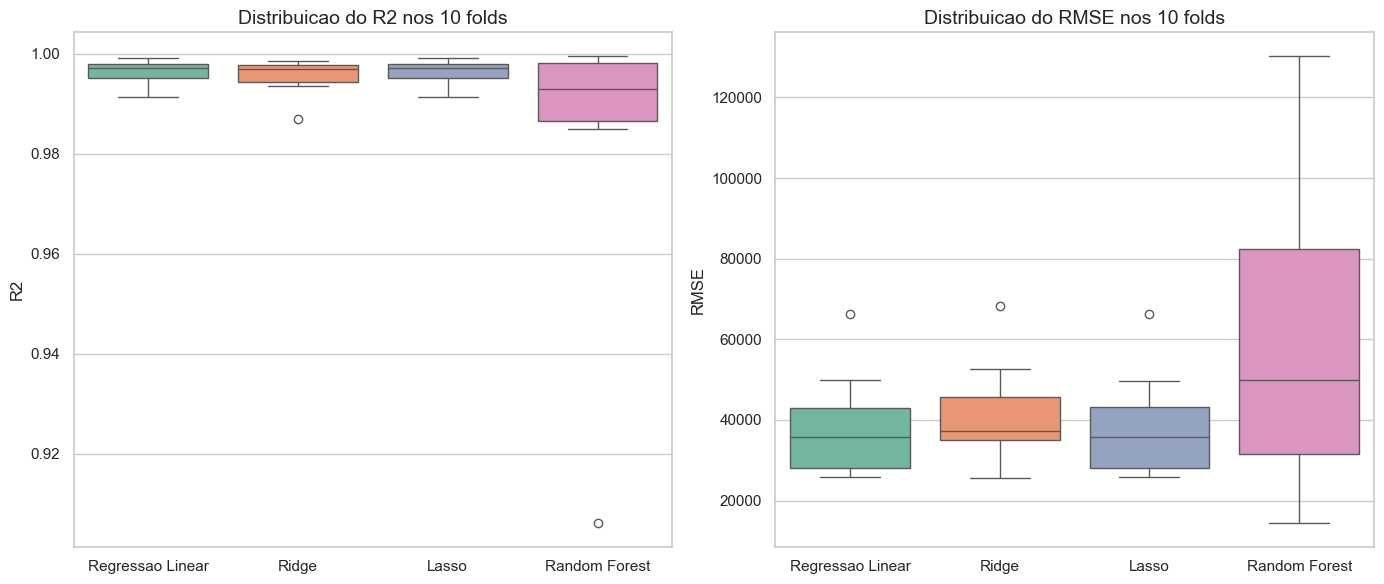

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.boxplot(
    data=cv_fold_results_df,
    x="Modelo",
    y="R2",
    ax=axes[0],
    palette="Set2",
)
axes[0].set_title("Distribuicao do R2 nos 10 folds")
axes[0].set_xlabel("")
axes[0].set_ylabel("R2")

sns.boxplot(
    data=cv_fold_results_df,
    x="Modelo",
    y="RMSE",
    ax=axes[1],
    palette="Set2",
)
axes[1].set_title("Distribuicao do RMSE nos 10 folds")
axes[1].set_xlabel("")
axes[1].set_ylabel("RMSE")

plt.tight_layout()
plt.show()


## 9. Comparação entre valores reais e previstos

O gráfico de valores reais vs. valores previstos permite avaliar visualmente a qualidade das previsões no conjunto de teste da validação Hold-out.

Quando os pontos se aproximam da linha diagonal, significa que as previsões estão próximas dos valores reais. Desvios acentuados relativamente a essa linha indicam erros de previsão mais elevados.

Este gráfico complementa as métricas quantitativas, permitindo identificar padrões de subestimação ou sobrestimação dos modelos.

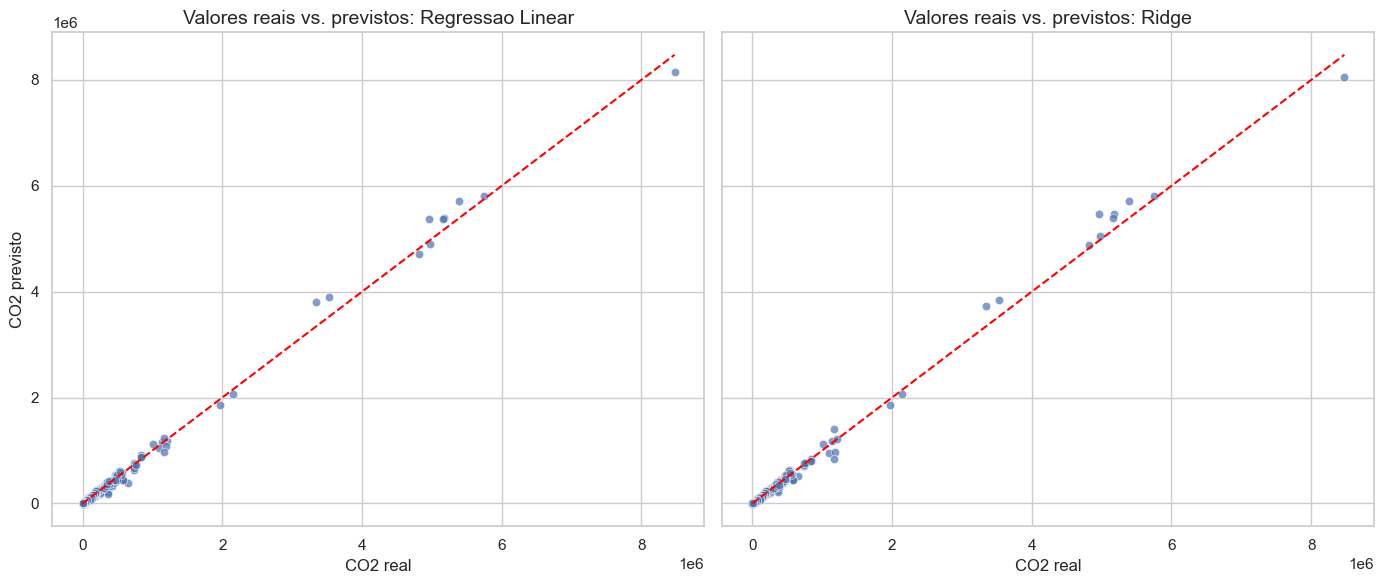

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

for ax, (model_name, y_pred) in zip(axes, holdout_predictions.items()):
    sns.scatterplot(x=y_test, y=y_pred, ax=ax, alpha=0.7)

    min_value = min(y_test.min(), np.min(y_pred))
    max_value = max(y_test.max(), np.max(y_pred))
    ax.plot([min_value, max_value], [min_value, max_value], color="red", linestyle="--")

    ax.set_title(f"Valores reais vs. previstos: {model_name}")
    ax.set_xlabel("CO2 real")
    ax.set_ylabel("CO2 previsto")

plt.tight_layout()
plt.show()


## 10. Conclusão

Os resultados mostram que a Regressão Linear apresenta o melhor desempenho global. Na validação Hold-out, este modelo obteve menor MAE, menor RMSE e maior R² do que o Random Forest. Na validação cruzada, apesar de o Random Forest apresentar um MAE médio mais baixo, a Regressão Linear apresenta menor RMSE médio, maior R² médio e menor variabilidade entre folds.

Assim, conclui-se que a Regressão Linear é o modelo mais adequado para este problema, uma vez que apresenta melhor capacidade explicativa, menor erro global e maior estabilidade. Além disso, por ser um modelo mais simples e interpretável, permite compreender de forma mais clara a relação entre as variáveis explicativas e as emissões de CO₂.